# Phase 13 — Xception Upgrade (Spatial Stream)

**Objective:** Replace the EfficientNetB0 spatial backbone with Xception, the architecture specified in the original proposal. Xception uses depthwise separable convolutions that are specifically effective at detecting micro-texture inconsistencies — the irregular skin pores, mismatched lighting, and boundary artifacts left by GAN generators. The frequency stream remains EfficientNetB0 at 128×128. Only the spatial stream changes.

## Context: Why Xception for the Spatial Stream

The Phase 10 dual-stream using EfficientNetB0 achieved:

| Model | Accuracy | Specificity | AUC-ROC |
|---|---|---|---|
| Dual-Stream EfficientNetB0 (Phase 10) | 0.8541 | 0.8458 | 0.9305 |
| **Dual-Stream Xception (this phase)** | *(target: improve on all)* | | |

Xception differs from EfficientNetB0 in one important way for this task: its depthwise separable convolutions process spatial channels independently before combining them. This makes the spatial stream more sensitive to point-like artifacts — irregular pixel clusters and edge discontinuities that GANs leave in local spatial patches — which EfficientNetB0's compound scaling misses.

**What changes in this phase:**
- Spatial stream backbone: EfficientNetB0 → Xception
- Input resolution: 128×128 → 299×299 (Xception minimum)
- DCT stream: unchanged (EfficientNetB0, 299×299 DCT map)
- Everything else: identical to Phase 10

## Import Libraries

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import Xception, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import Sequence

2026-06-09 01:12:52.946404: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780967573.147694      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780967573.204922      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780967573.690989      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780967573.691030      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780967573.691033      23 computation_placer.cc:177] computation placer alr

## Configuration & Paths

In [2]:
BASE_PATH      = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images"
TRAIN_PATH     = os.path.join(BASE_PATH, "train")
TEST_PATH      = os.path.join(BASE_PATH, "test")
RESULT_DIR     = "/kaggle/working/results/xception_dual"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
MODEL_DIR      = "/kaggle/working/models"

os.makedirs(RESULT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,      exist_ok=True)

IMG_SIZE        = (299, 299)   # Xception requires minimum 299x299
BATCH_SIZE      = 16           # Reduced from 32 — Xception is larger, needs more VRAM
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 10
CLASS_MAP       = {"FAKE": 1, "REAL": 0}

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices("GPU"))
print("IMG_SIZE   :", IMG_SIZE)
print("BATCH_SIZE :", BATCH_SIZE, "(reduced for Xception memory footprint)")

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
IMG_SIZE   : (299, 299)
BATCH_SIZE : 16 (reduced for Xception memory footprint)


## Define DCT Preprocessing Function

The DCT pipeline is identical to all previous phases. The only change is the resize target — images are now resized to 299×299 to match Xception input requirements. The frequency content is preserved identically; more pixels simply give the frequency CNN more spectral resolution to work with.

In [3]:
def dct_preprocess(image):
    image = image.astype(np.uint8)
    gray  = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray  = cv2.resize(gray, (299, 299))          # Updated from 128 to match Xception input
    gray  = np.float32(gray)
    dct   = cv2.dct(gray)
    dct   = np.log(np.abs(dct) + 1)
    dct   = cv2.normalize(dct, None, 0, 1, cv2.NORM_MINMAX)
    dct   = np.stack([dct] * 3, axis=-1)
    return dct

## Define Dual-Stream Data Generator

The generator is identical to Phase 10. Images are now resized to 299×299 for both streams.

In [4]:
class DualStreamGenerator(Sequence):
    def __init__(self, directory, img_size=(299, 299), batch_size=16,
                 shuffle=True, class_map=None):
        self.img_size   = img_size
        self.batch_size = batch_size
        self.shuffle    = shuffle
        classes         = sorted(os.listdir(directory))
        self.class_map  = class_map or {cls: i for i, cls in enumerate(classes)}

        self.filepaths, self.labels = [], []
        for cls in classes:
            cdir = os.path.join(directory, cls)
            if not os.path.isdir(cdir):
                continue
            for f in os.listdir(cdir):
                if f.lower().endswith((".jpg", ".jpeg", ".png")):
                    self.filepaths.append(os.path.join(cdir, f))
                    self.labels.append(self.class_map[cls])

        self.filepaths = np.array(self.filepaths)
        self.labels    = np.array(self.labels)
        self.indices   = np.arange(len(self.filepaths))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.filepaths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_rgb = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        X_dct = np.zeros((len(batch_idx), *self.img_size, 3), dtype=np.float32)
        y     = self.labels[batch_idx].astype(np.float32)

        for i, path in enumerate(self.filepaths[batch_idx]):
            img = cv2.imread(path)
            if img is None:
                continue
            img_rgb             = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_rgb_resized     = cv2.resize(img_rgb, self.img_size).astype(np.float32) / 255.0
            X_rgb[i]            = img_rgb_resized
            X_dct[i]            = dct_preprocess(img_rgb)

        return (X_rgb, X_dct), y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

## Create Train / Validation / Test Generators

In [5]:
all_gen  = DualStreamGenerator(TRAIN_PATH, img_size=IMG_SIZE, batch_size=BATCH_SIZE,
                               shuffle=True, class_map=CLASS_MAP)
n_total  = len(all_gen.filepaths)
n_val    = int(n_total * 0.2)
shuffled = np.random.permutation(n_total)
train_idx, val_idx = shuffled[n_val:], shuffled[:n_val]


class DualStreamSubset(DualStreamGenerator):
    def __init__(self, parent, indices, batch_size=16, shuffle=True):
        self.filepaths  = parent.filepaths[indices]
        self.labels     = parent.labels[indices]
        self.img_size   = parent.img_size
        self.class_map  = parent.class_map
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.indices    = np.arange(len(self.filepaths))
        if self.shuffle:
            np.random.shuffle(self.indices)


train_gen = DualStreamSubset(all_gen, train_idx, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = DualStreamSubset(all_gen, val_idx,   batch_size=BATCH_SIZE, shuffle=False)
test_gen  = DualStreamGenerator(TEST_PATH, img_size=IMG_SIZE,
                                 batch_size=BATCH_SIZE, shuffle=False, class_map=CLASS_MAP)

# Verify balance before training
real_count = int(np.sum(train_gen.labels == 0))
fake_count = int(np.sum(train_gen.labels == 1))
print(f"Train REAL : {real_count}   FAKE : {fake_count}")
print(f"Val samples: {len(val_gen.filepaths)}")
print(f"Test samples: {len(test_gen.filepaths)}")

(X_rgb_s, X_dct_s), y_s = train_gen[0]
print(f"RGB batch  : {X_rgb_s.shape}")
print(f"DCT batch  : {X_dct_s.shape}")
unique, counts = np.unique(y_s, return_counts=True)
assert len(unique) == 2, "STOP: only one class in batch — CLASS_MAP is wrong"
print(f"Batch labels balanced: {dict(zip(unique.astype(int), counts))}")

Train REAL : 39997   FAKE : 40003
Val samples: 20000
Test samples: 20000
RGB batch  : (16, 299, 299, 3)
DCT batch  : (16, 299, 299, 3)
Batch labels balanced: {np.int64(0): np.int64(11), np.int64(1): np.int64(5)}


## Build Xception Dual-Stream Model

Two backbones are built inside separate `tf.name_scope` blocks to prevent Keras 3 layer name collisions. The spatial stream uses Xception with ImageNet weights. The frequency stream uses EfficientNetB0 without pretrained weights — random initialisation is correct here because ImageNet features are harmful on DCT frequency maps.

The fusion head is identical to Phase 10: concatenation → Dense(256) → Dropout(0.5) → Sigmoid.

In [6]:
def build_spatial_stream(stream_name):
    """
    Xception spatial stream — pretrained on ImageNet.
    Depthwise separable convolutions make this more sensitive
    to local micro-texture artifacts than EfficientNetB0.
    """
    with tf.name_scope(stream_name):
        inputs   = Input(shape=(299, 299, 3), name=f"{stream_name}_input")
        backbone = Xception(
            weights="imagenet",
            include_top=False,
            input_tensor=inputs
        )
        outputs  = backbone.output
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=stream_name)


def build_frequency_stream(stream_name):
    """
    EfficientNetB0 frequency stream — random initialisation.
    ImageNet weights are counterproductive on DCT maps.
    """
    with tf.name_scope(stream_name):
        inputs   = Input(shape=(299, 299, 3), name=f"{stream_name}_input")
        backbone = EfficientNetB0(
            weights=None,
            include_top=False,
            input_tensor=inputs
        )
        outputs  = backbone.output
    return tf.keras.Model(inputs=inputs, outputs=outputs, name=stream_name)


# === BUILD STREAMS ===
spatial_model   = build_spatial_stream("spatial")
frequency_model = build_frequency_stream("frequency")

# === DEFINE OUTER INPUTS ===
rgb_input = Input(shape=(299, 299, 3), name="rgb_input")
dct_input = Input(shape=(299, 299, 3), name="dct_input")

# === PASS INPUTS THROUGH STREAMS ===
rgb_features = GlobalAveragePooling2D(name="gap_spatial"  )(spatial_model(rgb_input))
dct_features = GlobalAveragePooling2D(name="gap_frequency")(frequency_model(dct_input))

# === FUSION HEAD ===
merged = Concatenate(name="feature_fusion")([rgb_features, dct_features])
x      = Dense(256, activation="relu",    name="fusion_dense"  )(merged)
x      = Dropout(0.5,                     name="fusion_dropout")(x)
output = Dense(1,   activation="sigmoid", name="output"        )(x)

dual_model = Model(inputs=[rgb_input, dct_input], outputs=output)

# Freeze spatial (pretrained) — train frequency freely from random init
spatial_model.trainable   = False
frequency_model.trainable = True

dual_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dual_model.summary()

I0000 00:00:1780967591.166012      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780967591.172004      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rgb_input           │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dct_input           │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial             │ (None, 10, 10,    │ 20,861,480 │ rgb_input[0][0]   │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frequency           │ (None, 10, 10,    │  4,049,571 │ dct_input[0][0]   │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_spatial         │ (None, 2048)      │          0 │ spatial[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap_frequency       │ (None, 1280)      │          0 │ frequency[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 3328)      │          0 │ gap_spatial[0][0… │
│ (Concatenate)       │                   │            │ gap_frequency[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dense        │ (None, 256)       │    852,224 │ feature_fusion[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_dropout      │ (None, 256)       │          0 │ fusion_dense[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │        257 │ fusion_dropout[0… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,763,532 (98.28 MB)

 Trainable params: 4,860,029 (18.54 MB)

 Non-trainable params: 20,903,503 (79.74 MB)

## Train — Frozen Spatial, Free Frequency

In [7]:
checkpoint_cb = ModelCheckpoint(
    os.path.join(CHECKPOINT_DIR, "xception_dual_best.keras"),
    monitor="val_accuracy", save_best_only=True, mode="max", verbose=1
)

earlystop_frozen = EarlyStopping(
    monitor="val_accuracy", patience=4,
    restore_best_weights=True, verbose=1
)

history_frozen = dual_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=[checkpoint_cb, earlystop_frozen]
)

os.makedirs(MODEL_DIR, exist_ok=True)
dual_model.save(os.path.join(MODEL_DIR, "xception_dual_after_frozen.keras"))
print("Frozen-stage model saved.")
print(f"Final frozen epoch — acc: {history_frozen.history['accuracy'][-1]:.4f}  "      f"val_acc: {history_frozen.history['val_accuracy'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1780967633.235637      71 service.cc:152] XLA service 0x7e0c60004690 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780967633.235676      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780967633.235680      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780967640.310125      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-09 01:14:12.058093: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 01:14:12.277434: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 01:14:14.800056: E external/local_xl

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8288 - loss: 0.3739
Epoch 1: val_accuracy improved from None to 0.91325, saving model to /kaggle/working/checkpoints/xception_dual_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/xception_dual_best.keras
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 1504s 279ms/step - accuracy: 0.8708 - loss: 0.3013 - val_accuracy: 0.9133 - val_loss: 0.2159
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9183 - loss: 0.2087
Epoch 2: val_accuracy improved from 0.91325 to 0.92330, saving model to /kaggle/working/checkpoints/xception_dual_best.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/xception_dual_best.keras
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 1257s 251ms/step - accuracy: 0.9201 - loss: 0.2031 - val_accuracy: 0.9233 - val_loss: 0.1937
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.9306 - loss: 0.1759
Epoch 3: val_accuracy improved from 0.92330 to 0.93170, saving model t

## Fine-Tune — Unfreeze Top 20 Xception Layers

The spatial stream (Xception) top 20 layers are unfrozen at a very low learning rate. The frequency stream remains fully trainable as it was trained from random initialisation and needs full gradient updates.

In [8]:
# Spatial stream: unfreeze top 20 layers only
spatial_model.trainable = True
for layer in spatial_model.layers[:-20]:
    layer.trainable = False

# Frequency stream: all layers remain fully trainable
frequency_model.trainable = True

dual_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

earlystop_cb = EarlyStopping(
    monitor="val_loss", patience=5,
    restore_best_weights=True, verbose=1
)

history_finetune = dual_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/10


2026-06-09 04:47:54.691438: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 04:47:54.834325: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 04:47:55.328815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 04:47:55.468529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 04:47:55.766641: E external/local_xla/xla/stream_

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9569 - loss: 0.1181
Epoch 1: val_accuracy improved from 0.93420 to 0.93805, saving model to /kaggle/working/checkpoints/xception_dual_best.keras

Epoch 1: finished saving model to /kaggle/working/checkpoints/xception_dual_best.keras
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 1547s 291ms/step - accuracy: 0.9687 - loss: 0.0853 - val_accuracy: 0.9380 - val_loss: 0.1950
Epoch 2/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9835 - loss: 0.0462
Epoch 2: val_accuracy improved from 0.93805 to 0.94505, saving model to /kaggle/working/checkpoints/xception_dual_best.keras

Epoch 2: finished saving model to /kaggle/working/checkpoints/xception_dual_best.keras
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 1435s 287ms/step - accuracy: 0.9842 - loss: 0.0441 - val_accuracy: 0.9451 - val_loss: 0.1784
Epoch 3/10
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.9894 - loss: 0.0287
Epoch 3: val_accuracy improved from 0.94505 to 0.94815, saving mode

## Plot Training History

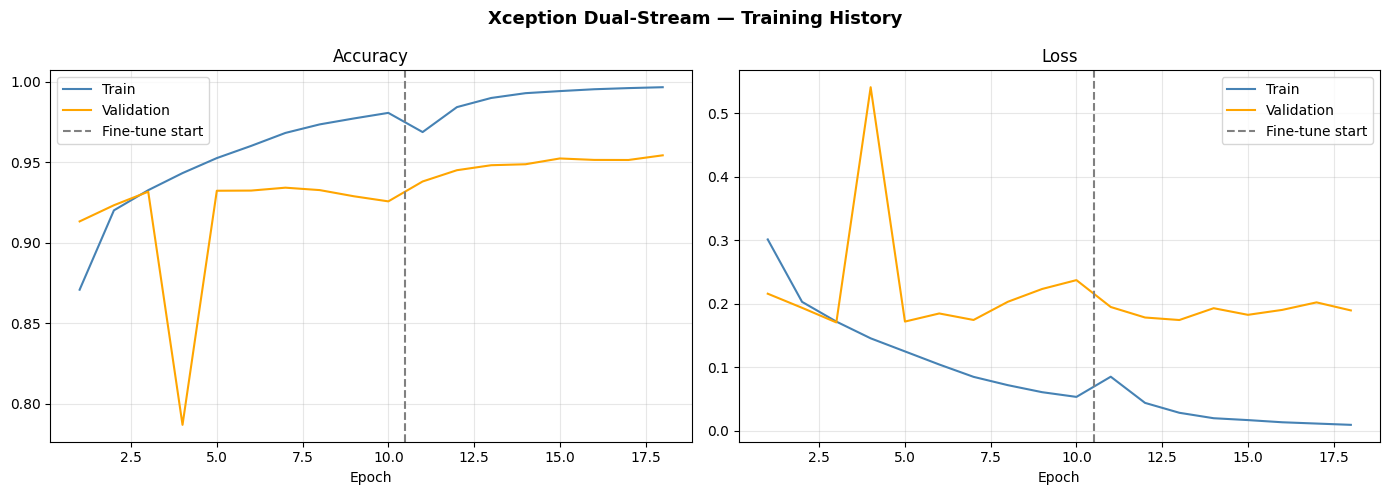

In [9]:
acc      = history_frozen.history["accuracy"]     + history_finetune.history["accuracy"]
val_acc  = history_frozen.history["val_accuracy"] + history_finetune.history["val_accuracy"]
loss     = history_frozen.history["loss"]         + history_finetune.history["loss"]
val_loss = history_frozen.history["val_loss"]     + history_finetune.history["val_loss"]
epochs_x = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Xception Dual-Stream — Training History", fontsize=13, fontweight="bold")

for ax, t_vals, v_vals, title in [
    (axes[0], acc,  val_acc,  "Accuracy"),
    (axes[1], loss, val_loss, "Loss"),
]:
    ax.plot(epochs_x, t_vals, label="Train",      color="steelblue")
    ax.plot(epochs_x, v_vals, label="Validation", color="orange")
    ax.axvline(x=EPOCHS_FROZEN + 0.5, color="gray", linestyle="--", label="Fine-tune start")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "xception_training_history.png"), dpi=150, bbox_inches="tight")
plt.show()

## Save Final Model

In [10]:
dual_model.save(os.path.join(MODEL_DIR, "xception_dual_final.keras"))
print("Model saved :", os.path.join(MODEL_DIR, "xception_dual_final.keras"))

Model saved : /kaggle/working/models/xception_dual_final.keras


## Evaluate on CIFAKE Test Set

XCEPTION DUAL-STREAM — EVALUATION RESULTS
  Accuracy      : 0.9491
  Precision     : 0.9578
  Recall        : 0.9396
  F1-Score      : 0.9486
  Specificity   : 0.9586
  AUC-ROC       : 0.9897
  TP=9396  FP=414  FN=604  TN=9586


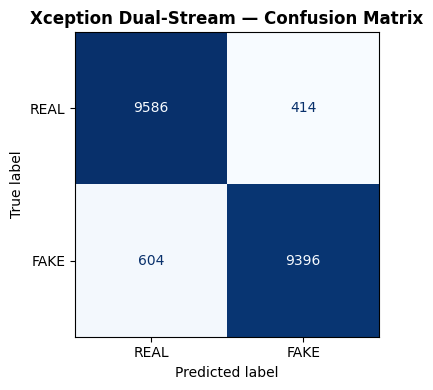

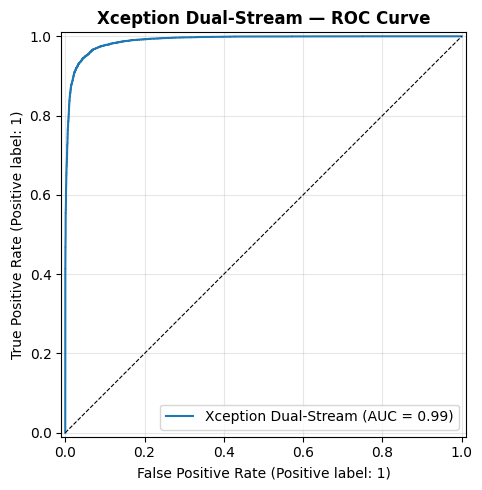

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

y_true_all, y_prob_all = [], []
for i in range(len(test_gen)):
    (X_rgb_b, X_dct_b), y_b = test_gen[i]
    probs = dual_model.predict([X_rgb_b, X_dct_b], verbose=0).flatten()
    y_true_all.extend(y_b)
    y_prob_all.extend(probs)

y_true = np.array(y_true_all)
y_prob = np.array(y_prob_all)
y_pred = (y_prob >= 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
spec = tn / (tn + fp)
auc  = roc_auc_score(y_true, y_prob)

XCEPTION_METRICS = {
    "Accuracy"    : acc,
    "Precision"   : prec,
    "Recall"      : rec,
    "F1-Score"    : f1,
    "Specificity" : spec,
    "AUC-ROC"     : auc,
}

print("=" * 50)
print("XCEPTION DUAL-STREAM — EVALUATION RESULTS")
print("=" * 50)
for k, v in XCEPTION_METRICS.items():
    print(f"  {k:<14}: {v:.4f}")
print("=" * 50)
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")

# Save report
with open(os.path.join(RESULT_DIR, "xception_eval_metrics.txt"), "w") as f:
    f.write("XCEPTION DUAL-STREAM EVALUATION\n" + "="*40 + "\n")
    for k, v in XCEPTION_METRICS.items():
        f.write(f"  {k:<14}: {v:.4f}\n")
    f.write(f"\n  TP={tp}  FP={fp}  FN={fn}  TN={tn}\n")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred),
                       display_labels=["REAL", "FAKE"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Xception Dual-Stream — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "xception_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_true, y_prob, ax=ax, name="Xception Dual-Stream")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("Xception Dual-Stream — ROC Curve", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "xception_roc_curve.png"), dpi=150, bbox_inches="tight")
plt.show()

## EfficientNetB0 vs Xception Comparison

EfficientNetB0 Dual  vs  Xception Dual — CIFAKE
Metric           EfficientNetB0     Xception     Winner
------------------------------------------------------------
Accuracy                 0.8541       0.9491   Xception
Precision                0.8483       0.9578   Xception
Recall                   0.8625       0.9396   Xception
F1-Score                 0.8554       0.9486   Xception
Specificity              0.8458       0.9586   Xception
AUC-ROC                  0.9305       0.9897   Xception


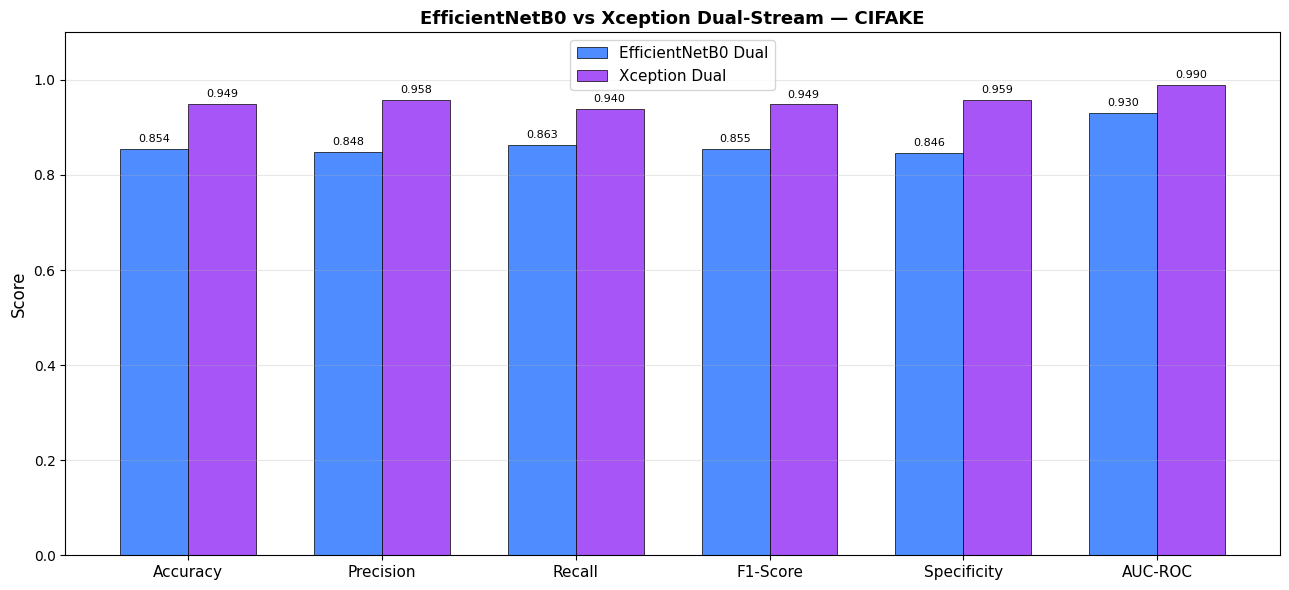

In [12]:
# Paste Phase 10 EfficientNetB0 results here for direct comparison
EFFICIENTNET_METRICS = {
    "Accuracy"    : 0.8541,
    "Precision"   : 0.8483,
    "Recall"      : 0.8625,
    "F1-Score"    : 0.8554,
    "Specificity" : 0.8458,
    "AUC-ROC"     : 0.9305,
}

metrics     = list(EFFICIENTNET_METRICS.keys())
eff_vals    = [EFFICIENTNET_METRICS[m] for m in metrics]
xcep_vals   = [XCEPTION_METRICS[m]    for m in metrics]

print("=" * 60)
print("EfficientNetB0 Dual  vs  Xception Dual — CIFAKE")
print("=" * 60)
print(f"{'Metric':<14} {'EfficientNetB0':>16} {'Xception':>12} {'Winner':>10}")
print("-" * 60)
for m, e, x in zip(metrics, eff_vals, xcep_vals):
    winner = "Xception" if x > e else ("EffNet" if e > x else "Tie")
    print(f"{m:<14} {e:>16.4f} {x:>12.4f} {winner:>10}")
print("=" * 60)

x_pos  = np.arange(len(metrics))
width  = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x_pos - width/2, eff_vals,  width, label="EfficientNetB0 Dual",
            color="#4e8cff", edgecolor="black", linewidth=0.5)
b2 = ax.bar(x_pos + width/2, xcep_vals, width, label="Xception Dual",
            color="#a855f7", edgecolor="black", linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("EfficientNetB0 vs Xception Dual-Stream — CIFAKE",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, "efficientnet_vs_xception.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Phase 13 Complete

| Component | Detail |
|---|---|
| Spatial stream | Xception (ImageNet weights) |
| Frequency stream | EfficientNetB0 (random init) |
| Input resolution | 299×299 |
| Batch size | 16 (reduced for Xception VRAM) |
| Frozen training | 10 epochs @ lr=1e-4 |
| Fine-tune | 10 epochs @ lr=1e-5 (top 20 Xception layers) |
| Fusion | Concatenation → Dense(256) → Dropout(0.5) → Sigmoid |

**Next → Phase 14: FaceForensics++ Domain Adaptation**

## Download Phase 13 Outputs

In [13]:
import shutil

OUTPUT_FILES = [
    os.path.join(MODEL_DIR,   "xception_dual_final.keras"),
    os.path.join(RESULT_DIR,  "xception_training_history.png"),
    os.path.join(RESULT_DIR,  "xception_confusion_matrix.png"),
    os.path.join(RESULT_DIR,  "xception_roc_curve.png"),
    os.path.join(RESULT_DIR,  "xception_eval_metrics.txt"),
    os.path.join(RESULT_DIR,  "efficientnet_vs_xception.png"),
    os.path.join(CHECKPOINT_DIR, "xception_dual_best.keras"),
]

os.makedirs("/kaggle/working/phase_13_bundle", exist_ok=True)
for f in OUTPUT_FILES:
    if os.path.exists(f):
        shutil.copy(f, "/kaggle/working/phase_13_bundle/")

shutil.make_archive("/kaggle/working/phase_13_outputs", "zip", "/kaggle/working/phase_13_bundle")

print("Files packaged:")
for f in OUTPUT_FILES:
    exists = os.path.exists(f)
    size   = round(os.path.getsize(f) / (1024 * 1024), 2) if exists else 0
    print(f"  {'OK' if exists else 'MISSING':<8} {os.path.basename(f):<45} {size} MB")

print()
print("Download: /kaggle/working/phase_13_outputs.zip")
print()
print("IMPORTANT: xception_dual_final.keras is required by Phase 14.")

Files packaged:
  OK       xception_dual_final.keras                     192.7 MB
  OK       xception_training_history.png                 0.1 MB
  OK       xception_confusion_matrix.png                 0.02 MB
  OK       xception_roc_curve.png                        0.05 MB
  OK       xception_eval_metrics.txt                     0.0 MB
  OK       efficientnet_vs_xception.png                  0.06 MB
  OK       xception_dual_best.keras                      192.7 MB

Download: /kaggle/working/phase_13_outputs.zip

IMPORTANT: xception_dual_final.keras is required by Phase 14.
